In [15]:
import pandas as pd
df = pd.read_csv('../data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [17]:
# Step 4: transform/scaling using scaler
import joblib

scaler = joblib.load("../models/scaler.pkl")
X_scaled = scaler.transform(X)

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

In [19]:
import joblib

pca = joblib.load('../models/pca.pkl')
X_pca = pca.transform(X_scaled)

kmeans = joblib.load('../models/kmeans_model.pkl')
labels = kmeans.predict(X_pca)

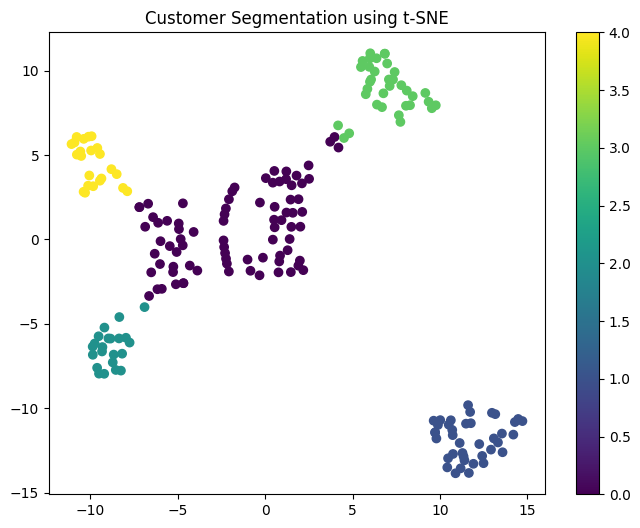

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap='viridis')
plt.title("Customer Segmentation using t-SNE")
plt.colorbar()
plt.show()